# Predicting Heart Disease — EDA
Kaggle Playground Series S6E2 | Binary classification: Absence / Presence of heart disease

## Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## Data Loading

In [2]:
KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

## Initial Data Inspection

In [3]:
# size of dataset
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Submission expected shape: {ss.shape}')
# look at first few rows
train.head(5)


Train shape: (630000, 15)
Test shape: (270000, 14)
Submission expected shape: (270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [7]:
test.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
mean,764999.500000,54.159870,0.716315,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,77942.430678,8.255471,0.450787,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,630000.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,697499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,764999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,832499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000
max,899999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.00000,7.000000


# Data Cleaning and Casting

## Cleaning/Casting Functions

In [8]:
import re
import pandas as pd

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r"\s+", "_", regex=True)
    )
    return df

train = clean_column_names(train)
test  = clean_column_names(test)

print("CLEAN TRAIN COLUMNS:", train.columns.tolist())

def cast_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Target: map Absence→0, Presence→1
    if "heart_disease" in df.columns:
        df["heart_disease"] = (
            df["heart_disease"].map({"Absence": 0, "Presence": 1}).astype("int8")
        )

    # Binary flags
    for col in ["sex", "fbs_over_120", "exercise_angina"]:
        if col in df.columns:
            df[col] = df[col].astype("int8")

    # Ordinal categoricals
    for col in ["chest_pain_type", "ekg_results", "slope_of_st",
                "number_of_vessels_fluro", "thallium"]:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # Continuous numeric
    for col in ["age", "bp", "cholesterol", "max_hr", "st_depression"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


CLEAN TRAIN COLUMNS: ['id', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium', 'heart_disease']


In [9]:
# Apply cleaning/casting functions
train = cast_features(train)
test  = cast_features(test)

In [10]:
target = "heart_disease"

categorical_features = [
    "sex",
    "chest_pain_type",
    "fbs_over_120",
    "ekg_results",
    "exercise_angina",
    "slope_of_st",
    "number_of_vessels_fluro",
    "thallium",
]

numeric_features = [
    "age",
    "bp",
    "cholesterol",
    "max_hr",
    "st_depression",
]


# EDA

## Feature Exploration and Data type



### Descriptions from the dataset


- **Sex**
  - Gender of the patient (1 = Male, 0 = Female).
  - Binary categorical; keep as 0/1 int or bool (optionally cast to categorical for EDA).

- **Chest pain type**
  - 1 = Typical angina; 2 = Atypical angina; 3 = Non-anginal pain; 4 = Asymptomatic.
  - Ordinal categorical; codes have a natural order, keep as small int or ordered categorical.

- **BP**
  - Resting blood pressure (mm Hg).
  - Continuous numeric feature.

- **Cholesterol**
  - Serum cholesterol level (mg/dL).
  - Continuous numeric feature.

- **FBS over 120**
  - Fasting blood sugar > 120 mg/dL (1 = True, 0 = False).
  - Binary categorical; 0/1 int or bool.

- **EKG results**
  - 0 = Normal; 1 = ST-T wave abnormality; 2 = Left ventricular hypertrophy.
  - Ordinal categorical; increasing abnormality, so the order is meaningful.

- **Max HR**
  - Maximum heart rate achieved.
  - Continuous numeric feature.

- **Exercise angina**
  - Exercise-induced angina (1 = Yes, 0 = No).
  - Binary categorical; 0/1 int or bool.

- **ST depression**
  - ST depression induced by exercise relative to rest.
  - Continuous numeric feature (can also be binned for plots).

- **Slope of ST**
  - Slope of the peak exercise ST segment.
  - Ordinal categorical; typically an ordered risk pattern (confirm exact code → order).

- **Number of vessels fluro**
  - Number of major vessels (0–3) colored by fluoroscopy.
  - Small integer count; can be treated as numeric or as a small ordered categorical.

- **Thallium**
  - Thallium stress test result (categorical medical indicator).
  - Categorical; treat as nominal unless you have documentation that defines an order.

- **Heart Disease (target)**
  - Presence vs absence of heart disease (usually 1 = disease, 0 = no disease).
  - Binary target; keep as 0/1 for classification and for computing group-wise positive rates.

## Target Distribution

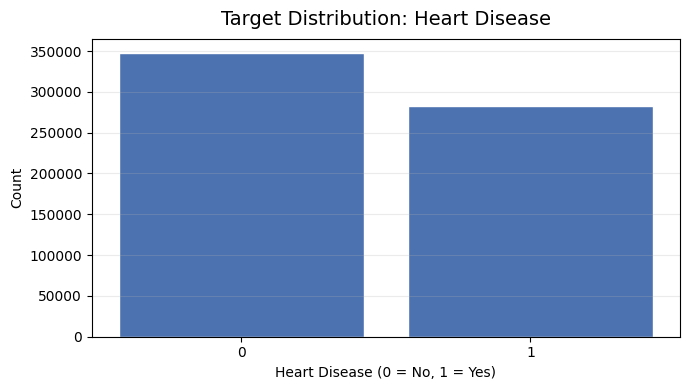

In [11]:
# Target distribution
plt.figure(figsize=(7, 4))
plt.hist(
    train["heart_disease"],
    bins=[-0.5, 0.5, 1.5],
    rwidth=0.85,
    color="#4C72B0",
    edgecolor="white",
)
plt.title("Target Distribution: Heart Disease", fontsize=14, pad=10)
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Features Visualizations

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats  # for point-biserial correlation

def explore_feature_vs_target(
    df: pd.DataFrame,
    feature: str,
    target: str = "heart_disease",
    kind: str = "auto",
    bins: int = 30,
):
    """
    Visualize relationship between a single feature and a binary target.
    kind:
      - 'numeric': force numeric style (boxplot + KDE + correlation)
      - 'categorical': force categorical style (rates + counts)
      - 'auto': decide based on dtype
    """
    if kind == "auto":
        if pd.api.types.is_numeric_dtype(df[feature]):
            kind = "numeric"
        else:
            kind = "categorical"

    if kind == "numeric":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # 1) Boxplot
        sns.boxplot(
            data=df, x=target, y=feature, ax=axes[0]
        )
        axes[0].set_title(f"{feature} by {target} (boxplot)")

        # 2) KDE / histogram by target
        sns.kdeplot(
            data=df, x=feature, hue=target,
            common_norm=False, ax=axes[1]
        )
        axes[1].set_title(f"{feature} distribution by {target} (KDE)")

        # 3) Point-biserial correlation
        # drop NaNs for correlation
        sub = df[[feature, target]].dropna()
        if len(sub) > 0:
            r_pb, p_val = stats.pointbiserialr(
                sub[target].astype(float),
                sub[feature].astype(float),
            )
            axes[2].axis("off")
            axes[2].text(
                0.0, 0.5,
                f"Point-biserial corr\nr = {r_pb:.3f}\np = {p_val:.2e}",
                fontsize=12,
            )
            axes[2].set_title("Correlation")
        else:
            axes[2].axis("off")
            axes[2].text(0.0, 0.5, "No data after dropna()", fontsize=12)

        fig.suptitle(f"{feature} vs {target}", fontsize=14)
        plt.tight_layout()
        plt.show()

    elif kind == "categorical":
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # 1) Positive rate per category
        rates = (
            df.groupby(feature)[target]
              .mean()
              .reset_index()
        )

        sns.barplot(
            data=rates, x=feature, y=target, ax=axes[0]
        )
        axes[0].set_ylabel(f"P({target}=1)")
        axes[0].set_title(f"{feature}: positive rate")

        # 2) Counts per category by class
        sns.countplot(
            data=df, x=feature, hue=target, ax=axes[1]
        )
        axes[1].set_title(f"{feature}: counts by {target}")

        for ax in axes:
            ax.tick_params(axis="x", rotation=30)

        fig.suptitle(f"{feature} vs {target}", fontsize=14)
        plt.tight_layout()
        plt.show()

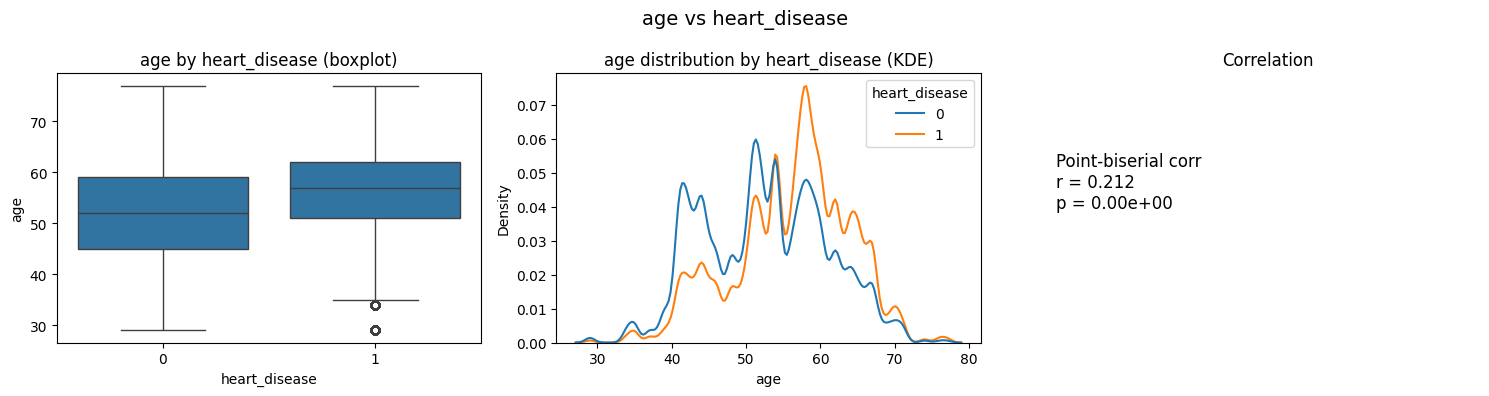

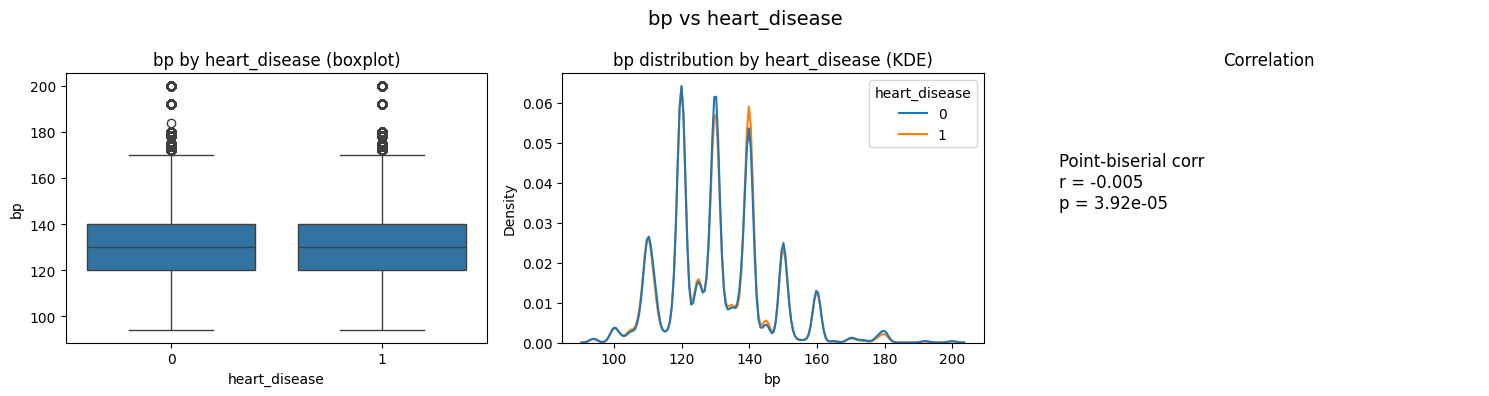

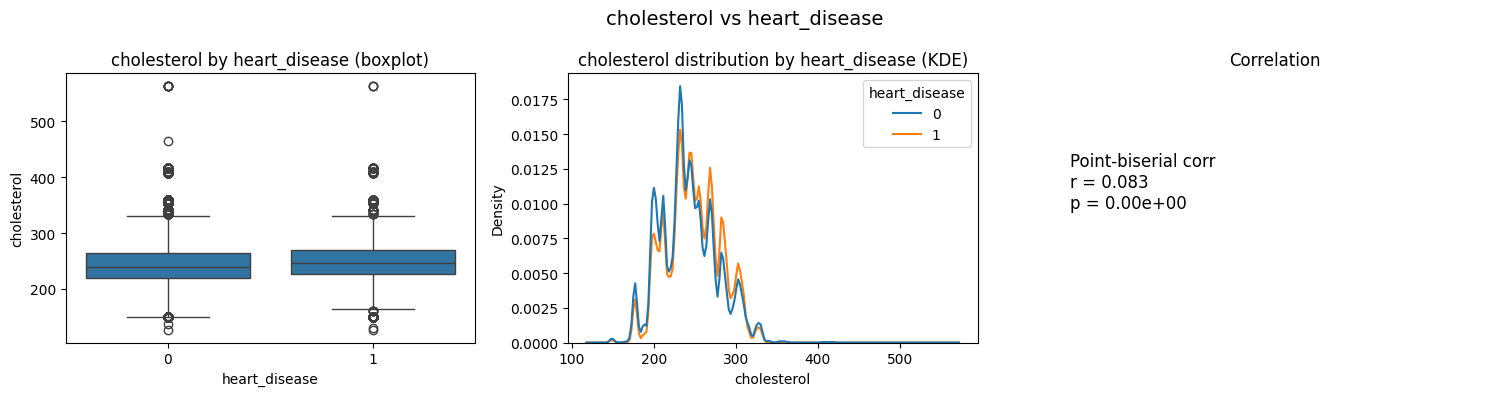

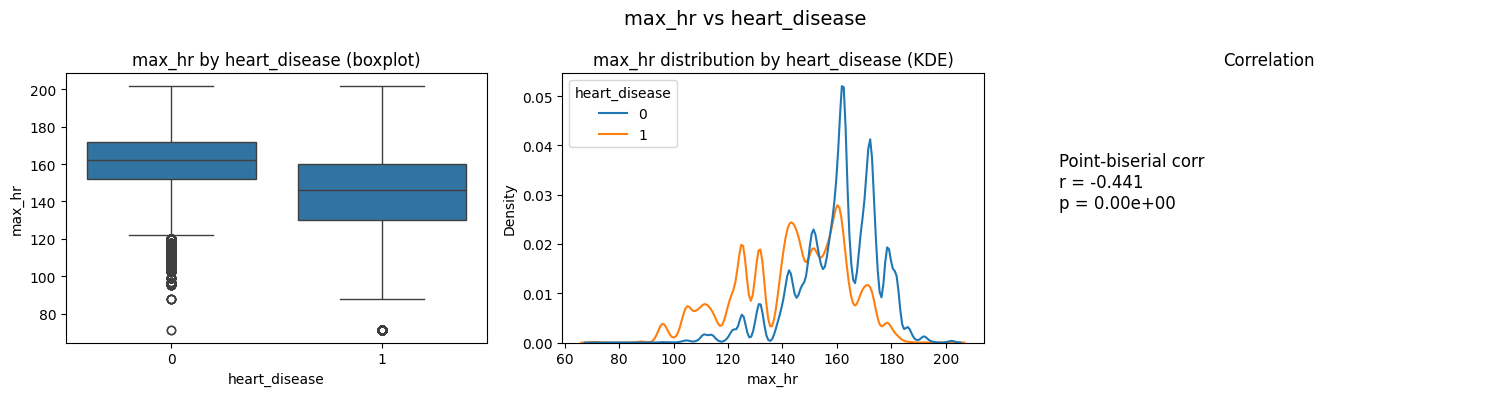

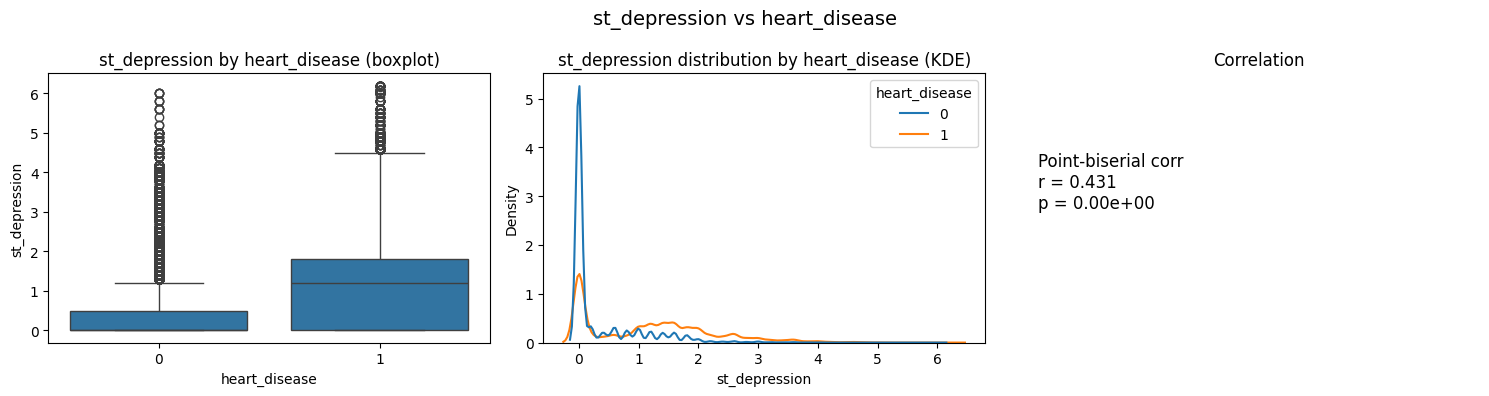

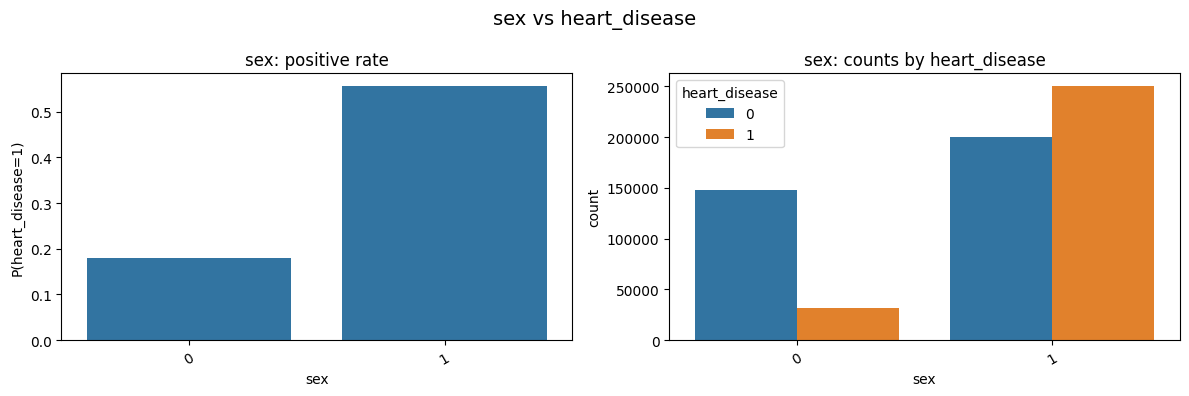

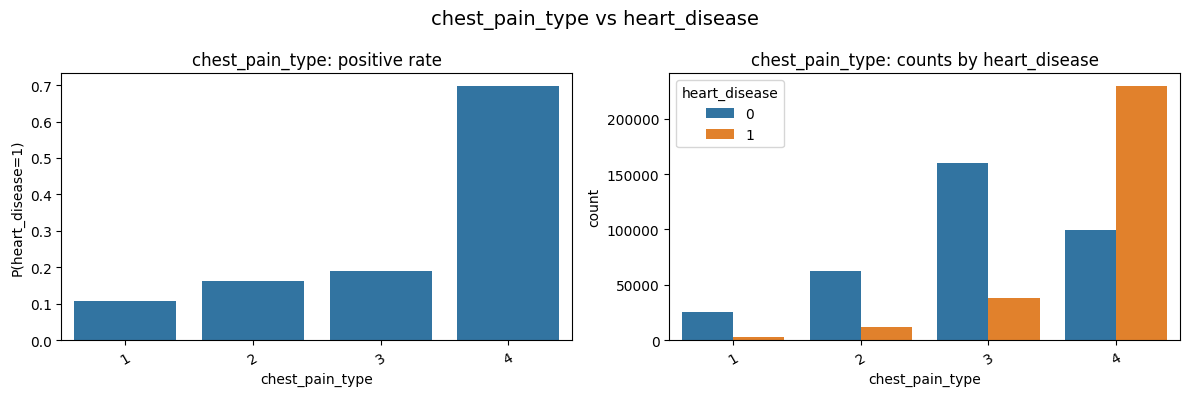

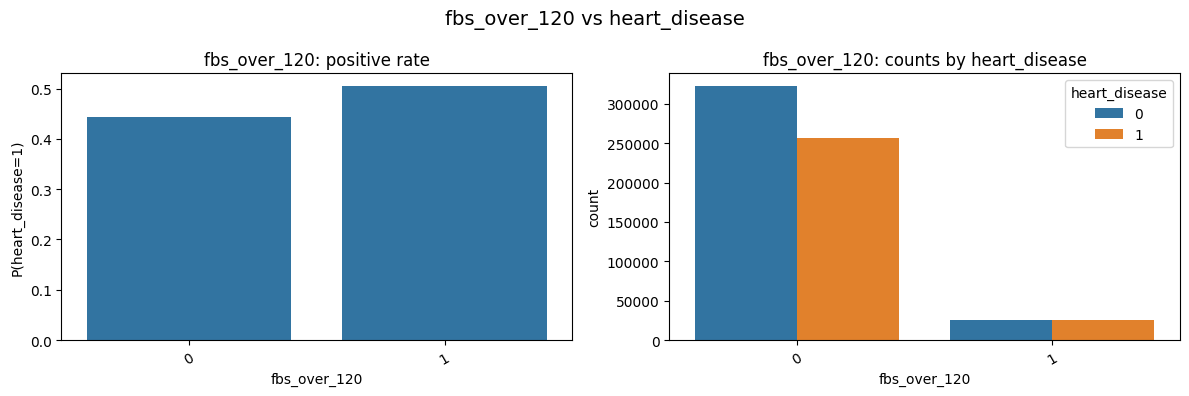

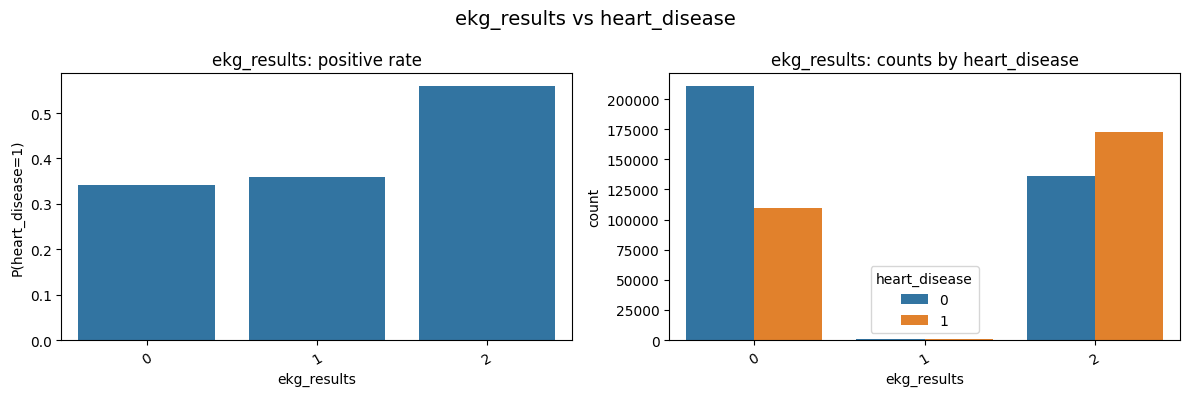

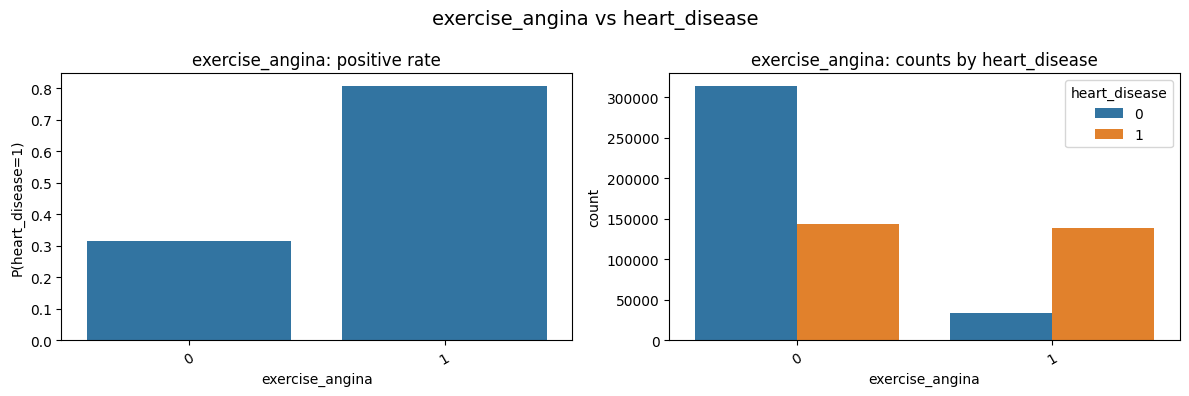

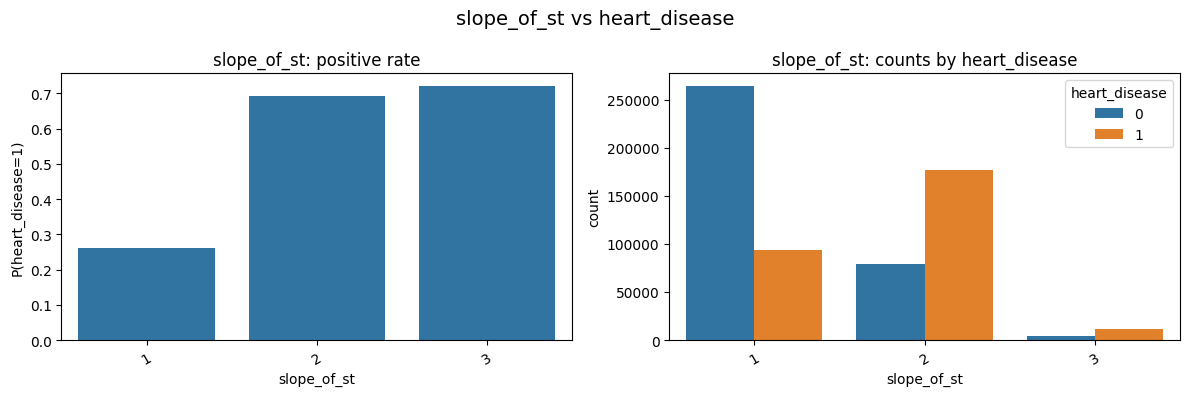

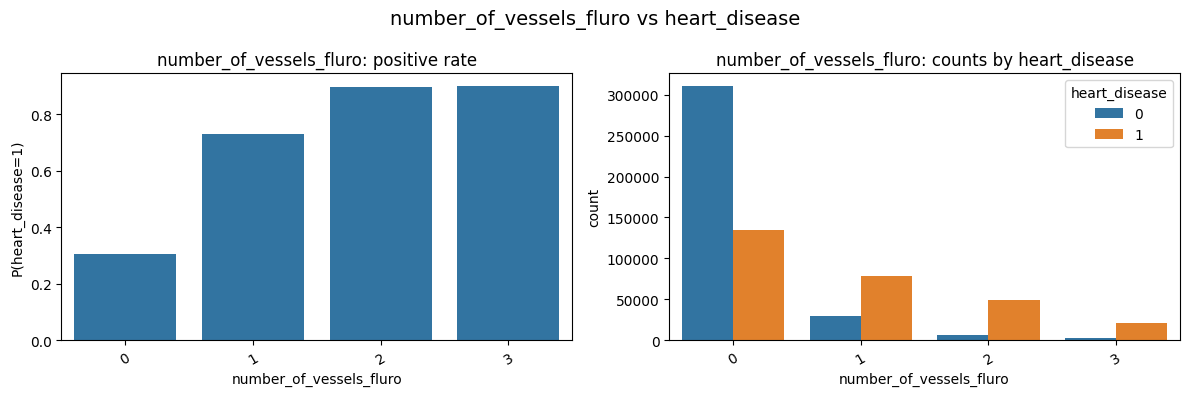

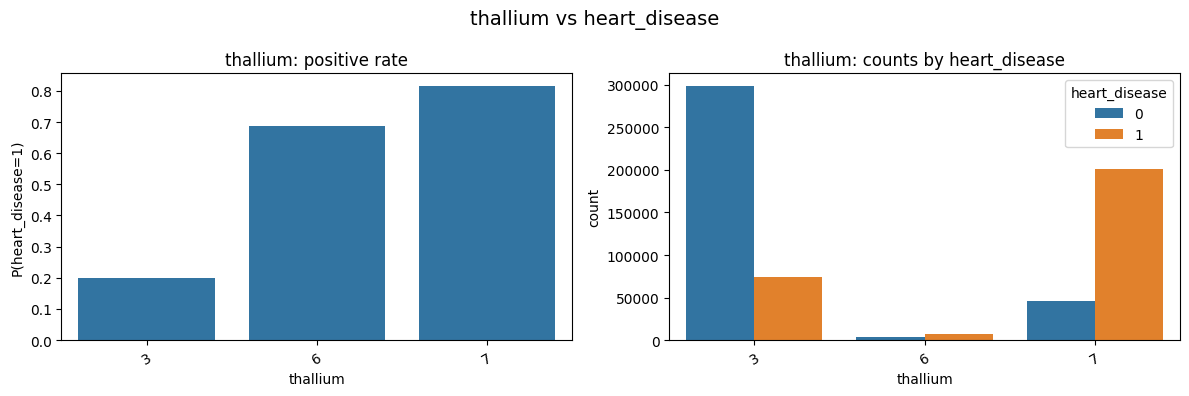

In [14]:
# Explore all numeric features vs target
for col in numeric_features:
    explore_feature_vs_target(train, feature=col, target=target, kind="numeric")

# Explore all categorical features vs target
for col in categorical_features:
    explore_feature_vs_target(train, feature=col, target=target, kind="categorical")


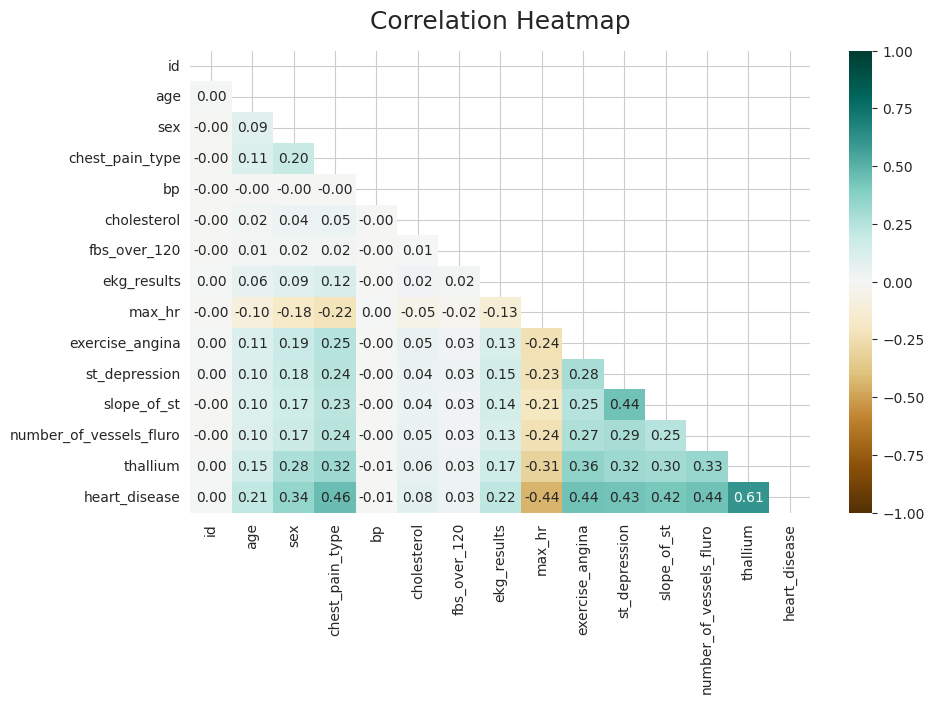

In [20]:
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(train.corr(),dtype=bool)) 
heatmap = sns.heatmap(train.corr(), mask=mask, vmin=-1, vmax=1, annot=True, cmap='BrBG', fmt=".2f") 
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

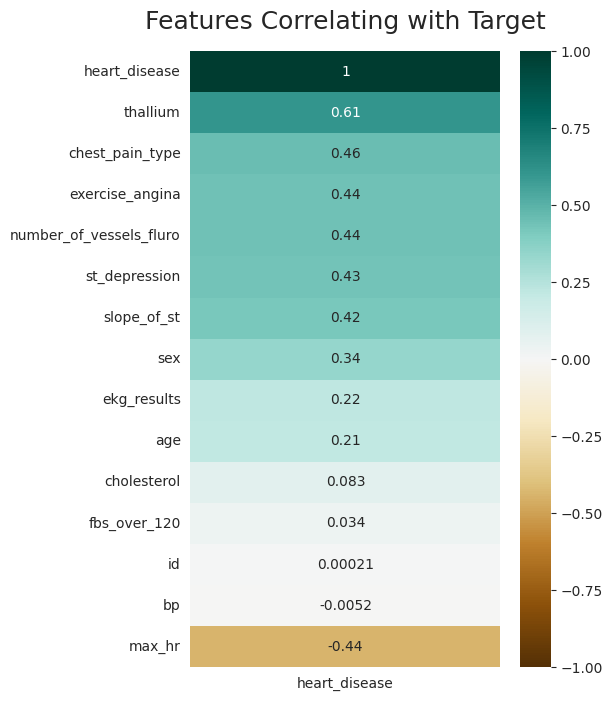

In [19]:
TARGET = 'heart_disease'
plt.figure(figsize=(5, 8)) # set size by num of features
heatmap = sns.heatmap(train.corr()[[TARGET]].sort_values(by=TARGET, ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG') 
heatmap.set_title('Features Correlating with Target', fontdict={'fontsize':18}, pad=16);

## EDA Summary & Feature Assessment

### Correlation Rankings (with `heart_disease`)

| Feature | r | Notes                                                                   |
|---|---|-------------------------------------------------------------------------|
| `thallium` | **0.61** | Strongest predictor by far                                              |
| `chest_pain_type` | 0.46 | Asymptomatic (type 4) dominates — counter-intuitive but well-documented |
| `exercise_angina` | 0.44 | Exercise-induced angina is a direct symptom                             |
| `max_hr` | −0.44 | Negative: lower max HR → more disease (reduced cardiac reserve)         |
| `number_of_vessels_fluro` | 0.44 | More occluded vessels = more disease                                    |
| `st_depression` | 0.43 | ST depression under exercise is a classic ischemia marker               |
| `slope_of_st` | 0.42 | Downsloping ST is the pathological pattern                              |
| `sex` | 0.34 | Males (1) significantly more prevalent in positive cases                |
| `ekg_results` | 0.22 | Moderate signal                                                         |
| `age` | 0.21 | Surprisingly weak — maybe attenuated by the dataset's age range (29–77) |
| `cholesterol` | 0.08 | Very weak — mean difference only ~5.6 mg/dL (242 vs 248)                |
| `fbs_over_120` | 0.03 | Negligible                                                              |
| `bp` | −0.005 | Effectively zero — mean BP nearly identical (130.6 vs 130.4 mm Hg)      |

---

### Other Observations


1. **Synthetic data provenance.** This dataset was generated from the original Cleveland Heart Disease dataset (n=303). Synthetic generation at 2,000x scale can dilute or distort weak-to-moderate relationships.

2. **Resting BP is a poor single-measurement proxy.** A single resting reading doesn't capture the sustained hypertension that drives long-term arterial damage (?).  Still goes against common knowledge that blood pressure is a high risk factor for heart disease.

3. **Total cholesterol is a weak predictor.** The clinically meaningful signal comes from LDL/HDL ratio and triglycerides — neither is present here. Total cholesterol obscures that distinction (?).  Why didn't they record LDL/HDL ratios then?

---

### Modeling Insights

- **Top predictors:** `thallium`, `chest_pain_type`, `exercise_angina`, `max_hr`, `number_of_vessels_fluro`, `st_depression`, `slope_of_st`
- **`bp` and `cholesterol`** will add little to linear models, but tree-based models may still extract non-linear interactions — don't drop them prematurely.
- **`thallium`** is so dominant (r=0.61), it may be encoding the diagnosis in the generated dataset.